# Simulated Annealing Tutorial ーHow to formulateー
This notebook explains the concept of formulation for combinatorial optimization.

To tackle this topic, we will examine the number partitioning problem as a representative example.

Let's implement a solution using SA!

## Preparation

In [ ]:
!pip install openjij
!pip install pyqubo

In [ ]:
import numpy as np

In [ ]:
import openjij as oj

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from pyqubo import Array

## Define the problem

Number Partitioning Problem is defined as below:

---
Given a list of positive integers: $$A = [a_1, a_2, \dots, a_N].$$
Find a partition into two sets such that the difference between the sums of the numbers in each set is minimized.

---

In [ ]:
N = 15  #problem size

In [ ]:
a_low = 1   #minimum integer of the problem
a_high = N  #maximum integer of the problem
A = np.random.randint(low=a_low, high=a_high, size=N)
A_sum = np.sum(A)

In [ ]:
print(f"{A=}")
print(f"{A_sum=}")

A=array([ 5, 14, 13,  3,  3, 11,  4,  2,  2, 14, 12, 11,  3,  1, 14])
A_sum=np.int64(112)


## Formulate

To formulate combinatorial optimization problems, we first need to clarify what we want to know.

We should split $A$ into $group_1$ and $group_2$ and we want to know the optimum partition.

So, we introduce $\vec{x}=(x_1,\dots, x_N)$ as
$$
x_i = \begin{cases}
    1 & (a_i\text{ is selected for group 1}) \\
    0 & (a_i\text{ is selected for group 2}).
  \end{cases}
$$

$$group_1 \subset \left\{1, \dots, N\right\}, group_2 = \left\{1, \dots, N\right\} - group_1$$


Next, we determine the objective of the optimization.
Specifically, it's helpful to consider what you want to maximize or minimize.

This problem want to minimize the difference between the sums of the numbers in each set.

Therefore, objective function can be defined as

$${\text{min}} \,\,\,\lvert \sum_{i \in C } a_i - \sum_{i \notin group_1 } a_i \rvert.$$

Expressing the above equation in terms of $\vec{x}$, the desired $\vec{x}^*$ is as follows:

\begin{align}
\vec{x}^*
&=\underset{\vec{x}}{\text{argmin}} \,\,\,\lvert \sum_{i=1}^N a_ix_i - \sum_{i=1}^N a_i(1-x_i) \rvert \\
&=\underset{\vec{x}}{\text{argmin}} \,\,\,(\sum_{i=1}^N a_ix_i - \sum_{i=1}^N a_i(1-x_i) )^2
\end{align}

Once you've gotten this far, all that's left is to convert it into a form that can be solved using SA. You can easily do this by referring to our sample code or asking ChatGPT.

This time, we shall convert to QUBO format using the pyqubo library.

In [ ]:
# variable values
x = Array.create('',shape=N, vartype='BINARY')

# objective function
H = (sum(A[i]*x[i] for i in range (N)) - sum(A[i]*(1-x[i]) for i in range (N)))**2

# compile to a model
model = H.compile()
qubo_dict, offset = model.to_qubo()

In [ ]:
print(qubo_dict)

{('[10]', '[2]'): 1248.0, ('[9]', '[1]'): 1568.0, ('[9]', '[7]'): 224.0, ('[7]', '[4]'): 48.0, ('[10]', '[6]'): 384.0, ('[8]', '[2]'): 208.0, ('[10]', '[4]'): 288.0, ('[10]', '[9]'): 1344.0, ('[7]', '[0]'): 80.0, ('[0]', '[0]'): -2140.0, ('[10]', '[10]'): -4800.0, ('[8]', '[5]'): 176.0, ('[8]', '[8]'): -880.0, ('[13]', '[5]'): 88.0, ('[1]', '[0]'): 560.0, ('[13]', '[3]'): 24.0, ('[8]', '[3]'): 48.0, ('[13]', '[6]'): 32.0, ('[14]', '[2]'): 1456.0, ('[13]', '[11]'): 88.0, ('[5]', '[0]'): 440.0, ('[9]', '[6]'): 448.0, ('[11]', '[0]'): 440.0, ('[9]', '[8]'): 224.0, ('[5]', '[1]'): 1232.0, ('[11]', '[8]'): 176.0, ('[13]', '[10]'): 96.0, ('[13]', '[9]'): 112.0, ('[8]', '[1]'): 224.0, ('[10]', '[7]'): 192.0, ('[13]', '[13]'): -444.0, ('[11]', '[7]'): 176.0, ('[12]', '[5]'): 264.0, ('[11]', '[3]'): 264.0, ('[5]', '[3]'): 264.0, ('[14]', '[12]'): 336.0, ('[12]', '[9]'): 336.0, ('[12]', '[12]'): -1308.0, ('[12]', '[11]'): 264.0, ('[4]', '[3]'): 72.0, ('[7]', '[5]'): 176.0, ('[7]', '[2]'): 208.0,

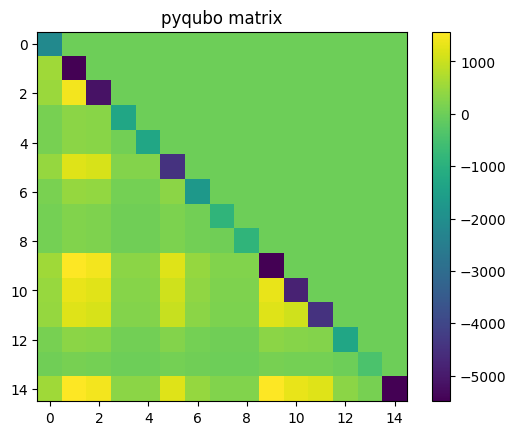

In [ ]:
import re
# Show QUBO heatmap
QUBO = np.zeros((N,N))
for (x_i,x_j) in qubo_dict.keys():
    i = int(re.findall(r'\d+', x_i)[0])
    j = int(re.findall(r'\d+', x_j)[0])
    QUBO[i][j] = qubo_dict[(x_i,x_j)]

plt.imshow(QUBO)
plt.colorbar()
plt.title('pyqubo matrix')
plt.show()

## (Extra:do not have to do it)Convert to QUBO format

Calculate the objective function as follows:

\begin{align}
\vec{x}^*
&=\underset{\vec{x}}{\text{argmin}} \,\,\,\lvert \sum_{i=1}^N a_ix_i - \sum_{i=1}^N a_i(1-x_i) \rvert \\
&=\underset{\vec{x}}{\text{argmin}} \,\,\,(\sum_{i=1}^N a_ix_i - \sum_{i=1}^N a_i(1-x_i) )^2 \\
&=\underset{\vec{x}}{\text{argmin}} \,\,\,(2\sum_{i=1}^N a_ix_i - \sum_{i=1}^N a_i)^2 \\
&=\underset{\vec{x}}{\text{argmin}} \,\,\,(4(\sum_{i=1}^N a_ix_i)^2 - 4\sum_{i=1}^N\sum_{j=1}^N a_ia_jx_i+(\sum_{i=1}^N a_i)^2) \\
&=\underset{\vec{x}}{\text{argmin}} \,\,\,(4\sum_{i=1}^N \sum_{j=1}^N a_ia_jx_ix_j - 4\sum_{i=1}^N a_i (\sum_{j=1}^N a_j)x_i)
\end{align}

Therefore, QUBO can be constructed.

In [ ]:
QUBO = np.zeros((N,N))

for i in range(N):
    for j in range(N):
        QUBO[i][j] = 4*A[i]*A[j]
        if i==j:
            QUBO[i][j] -= 4*A[i]*A_sum

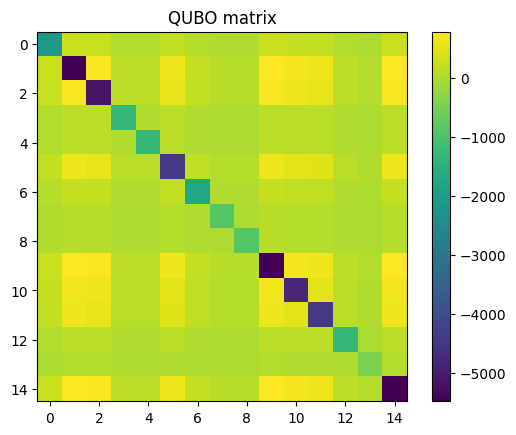

In [ ]:
# Show QUBO heatmap
plt.imshow(QUBO)
plt.colorbar()
plt.title('QUBO matrix')
plt.show()

## Solve the problem with SA

In [ ]:
# Conduct Simulated Annealing
num_reads = 300
num_sweeps = 1000
sampler = oj.SASampler()
sampleset = sampler.sample_qubo(QUBO, num_reads=num_reads, num_sweeps=num_sweeps)

In [ ]:
print(sampleset.first.sample)

{0: np.int8(0), 1: np.int8(1), 2: np.int8(0), 3: np.int8(0), 4: np.int8(1), 5: np.int8(0), 6: np.int8(0), 7: np.int8(1), 8: np.int8(0), 9: np.int8(0), 10: np.int8(1), 11: np.int8(1), 12: np.int8(0), 13: np.int8(0), 14: np.int8(1)}


In [ ]:
# Obtain the solution of minimum objective value
x_star = np.array([sampleset.first.sample[i] for i in range(N)])

Finally, let's check the results.

In [ ]:
# See the result
print(f"{x_star=}")
print(f"A : {A}")
print(f"A_sum : {A_sum.item()}")
print(f"group_1 sum : {np.sum(A @ x_star)}")
print(f"group_2 sum : {np.sum(A @ (1-x_star))}")

x_star=array([0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1], dtype=int8)
A : [ 5 14 13  3  3 11  4  2  2 14 12 11  3  1 14]
A_sum : 112
group_1 sum : 56
group_2 sum : 56
